# Big Brothers Big Sisters Match Outcome Prediction

# Univeristy of Minnesota Duluth

# By: 
# Michael Williams 
# Tyler Zwakman 
# Kyle Luger 
# Shae LaDuke 
# iden Kilibarda 
# Max DeCarlo

# Due
# May 2, 2025

# Project Advisor:
# Professor Nik Rushdi

**Team 3 | BA4420 – Spring 2025**  
**Tools Used:** RStudio
**Dataset:** BBBS Novice (Closed Matches)

## Abstract

The goal of this project was to help Big Brothers Big Sisters (BBBS) better utilize their match data to identify early indicators of long-term mentorship success. Using the Novice dataset and performing analysis in RStudio, we developed predictive models and conducted exploratory analysis to uncover patterns associated with match longevity. Structured variables such as mentor/mentee demographics and program timelines were combined with sentiment scores derived from case narratives to enhance the data's predictive power. Our models forecast both expected match length and the likelihood of a match lasting at least 18 months—a key performance benchmark for BBBS. These results can be used to support match planning, prioritize support efforts, and improve overall program effectiveness through data-driven decision-making.

## Executive Summary

This report summarizes Team 3’s data science project focused on identifying patterns and building predictive models to support Big Brothers Big Sisters (BBBS) in improving mentorship outcomes. BBBS is a nonprofit organization dedicated to creating and supporting one-to-one mentoring relationships that ignite the potential of youth. The organization’s goal is to foster positive youth development by connecting children with caring adult mentors. A key challenge faced by BBBS is that not all matches last long enough to create a meaningful impact; longer-lasting matches are strongly associated with better social, emotional, and academic outcomes. To address this, BBBS seeks to identify which matches are most likely to succeed early in the process, enabling staff to proactively allocate support and resources where they are most needed.

Using the Novice dataset and performing all modeling and analysis in RStudio, we explored over 3,000 closed mentorship records. The data included structured variables such as demographic information, program type, and intake timelines, as well as unstructured narrative fields like rationale for match and closure details. We addressed common data quality issues, including missing values and inconsistent factor levels, through systematic preprocessing and feature engineering. New variables such as Age Gap, Activation Days, and sentiment scores were created to enrich the dataset. Exploratory data analysis using histograms, boxplots, and correlation matrices revealed trends in match duration and highlighted key linear associations and instances of multicollinearity, most notably between Big Age and Age Gap (r = 0.98).

We developed and evaluated four predictive models: linear regression, decision tree, random forest, and logistic regression. Linear regression provided a transparent benchmark model with interpretable coefficients. The decision tree offered rule-based insights that aligned with caseworker decision logic. The random forest classifier improved classification performance by modeling complex, non-linear interactions and ranking variable importance. Logistic regression reframed the objective as a binary classification problem and demonstrated a balance of accuracy and interpretability. Sentiment scores extracted from free-text fields added unique predictive value and underscored the potential of combining qualitative and quantitative data in social service contexts.

In conclusion, our models provide actionable insights that can inform BBBS operations. By integrating these predictive tools into their case management workflow, BBBS staff can flag high-risk matches during onboarding, tailor interventions, and ultimately increase the likelihood of successful, long-term mentor-mentee relationships. With further refinement and operational deployment, this work can serve as a foundation for data-driven decision-making at scale.

## Table of Contents
1. [Abstract](#abstract)  
2. [Executive Summary](#executive-summary)  
3. [Preprocessing & Feature Engineering](#preprocessing--feature-engineering)  
4. [Sentiment Scoring](#sentiment-scoring)  
5. [Exploratory Data Analysis](#exploratory-data-analysis)  
6. [Modeling](#modeling)
   - [Linear Regression](#linear-regression)
   - [Decision Tree](#decision-tree)
   - [Random Forest](#random-forest)
   - [Logistic Regression](#logistic-regression)
7. [Key Insights](#key-insights)
8. [Conclusion](#conclusion)
9. [Appendix](#appendix)


## Exploratory Data Analysis

These visuals help us understand match length patterns and the effect of key variables such as age, gender, and sentiment scores.

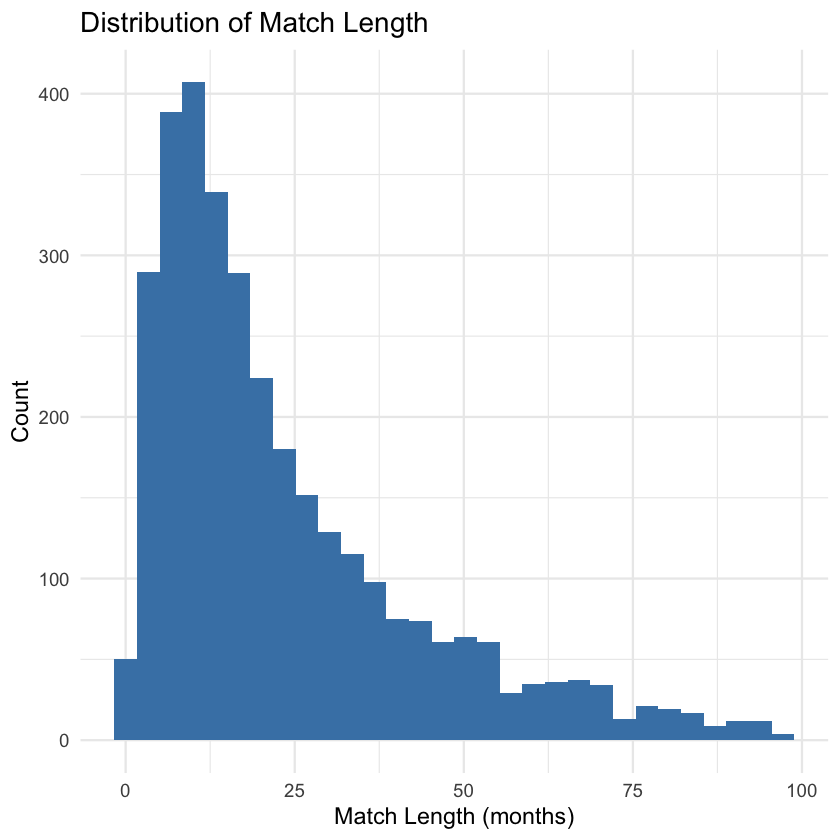

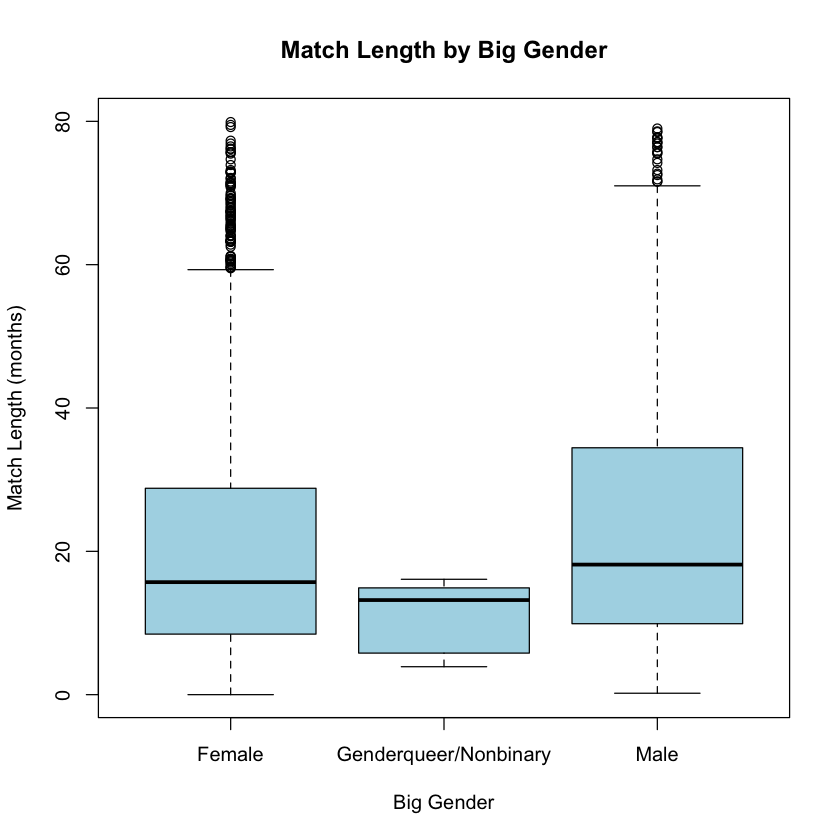

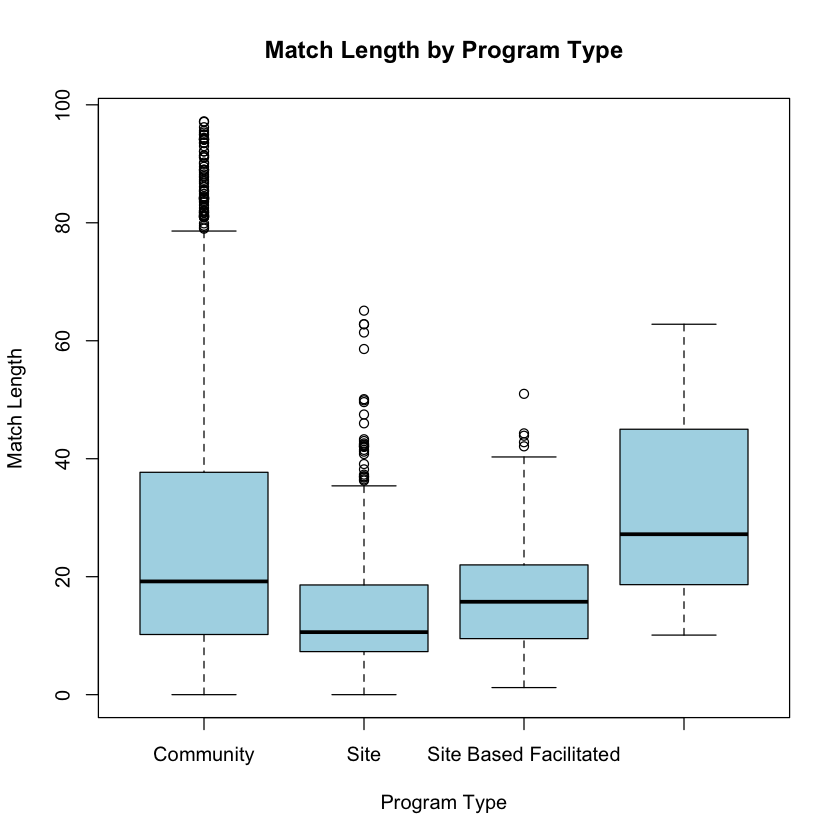

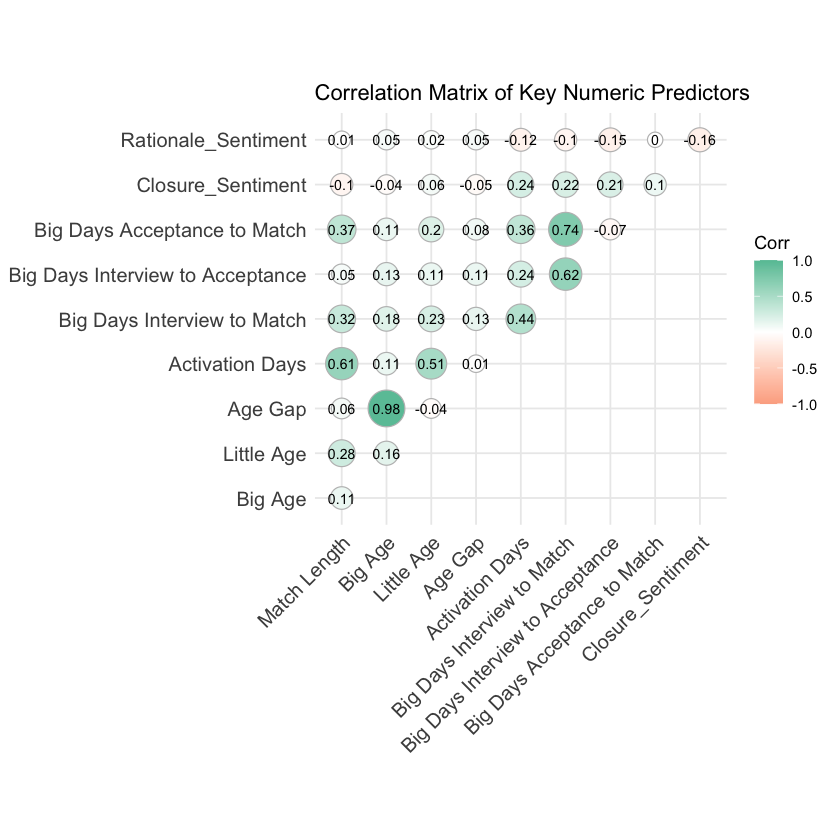

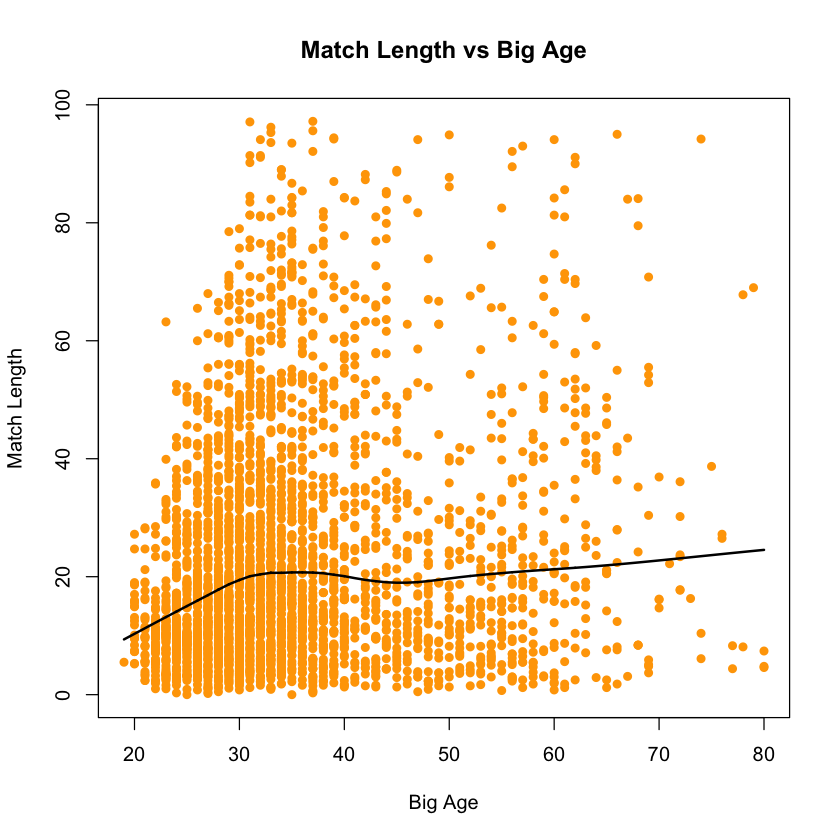

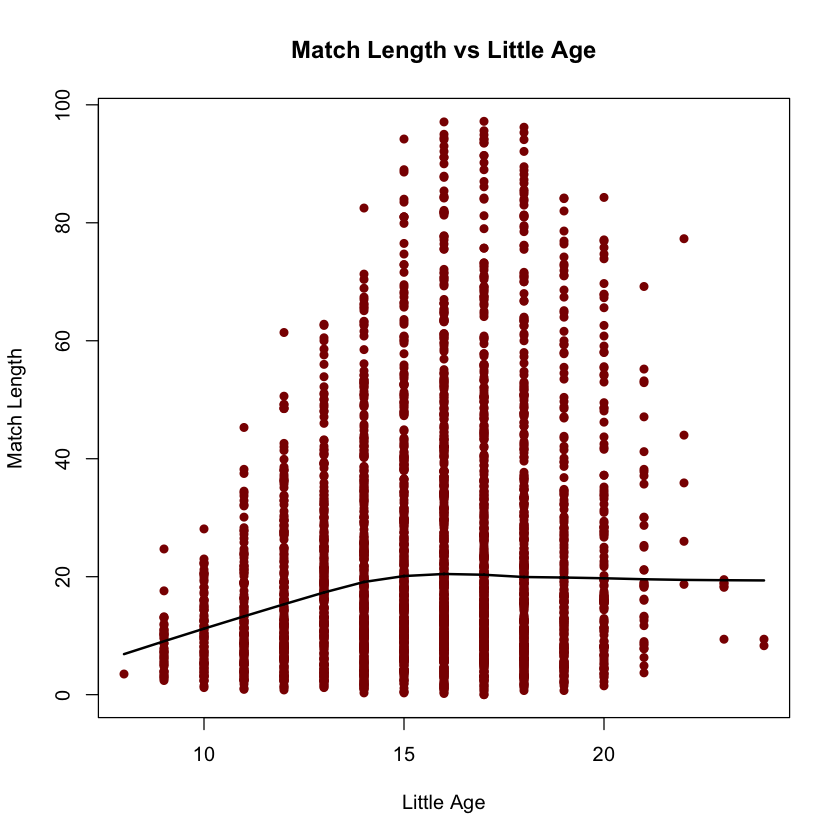

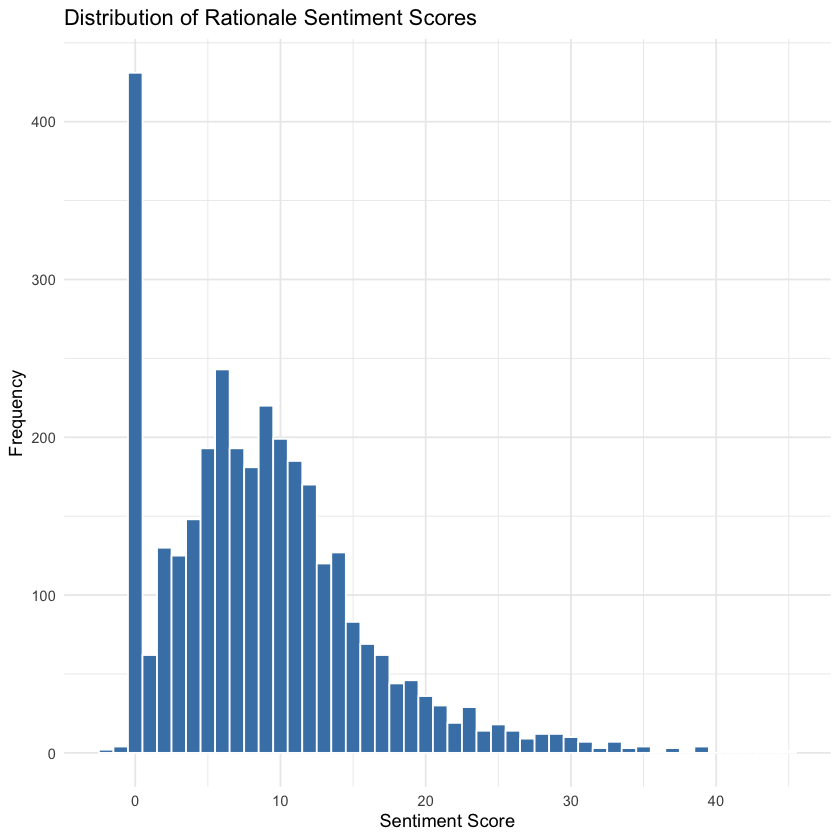

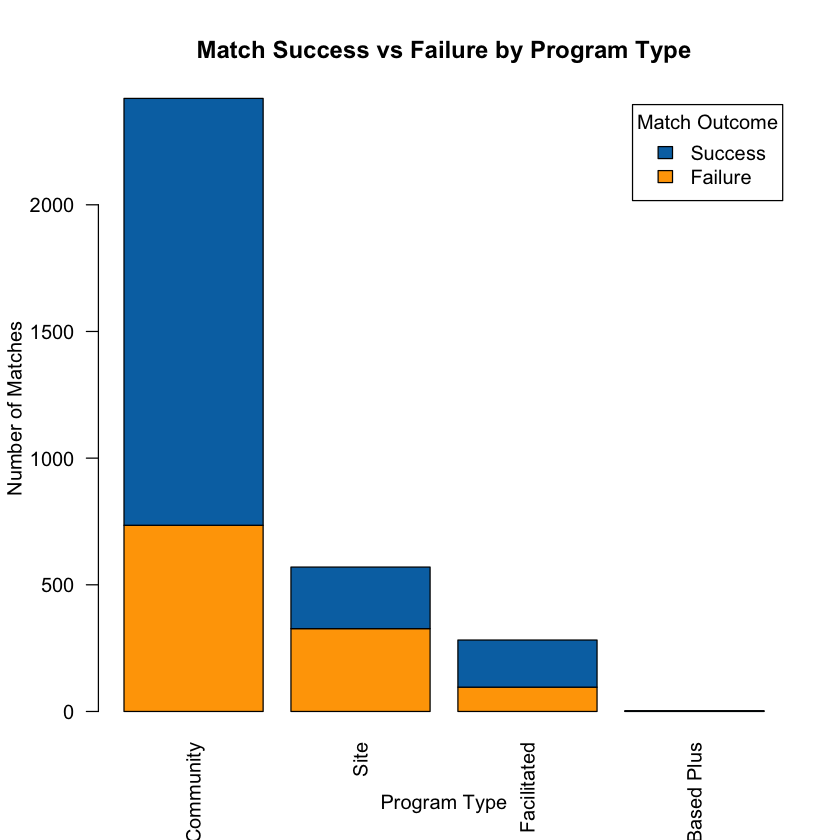

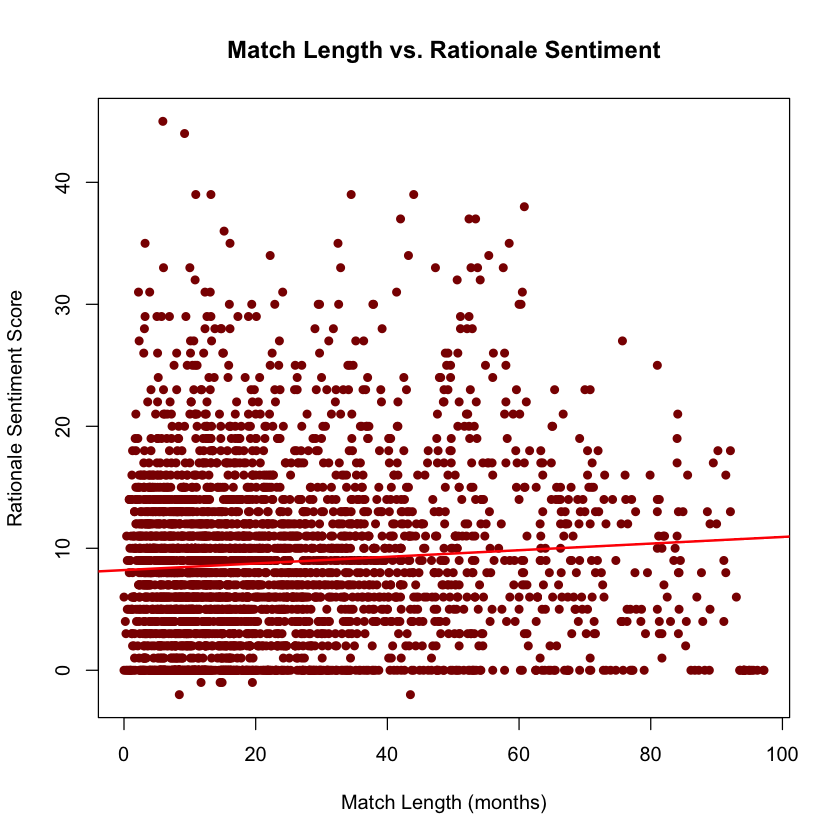

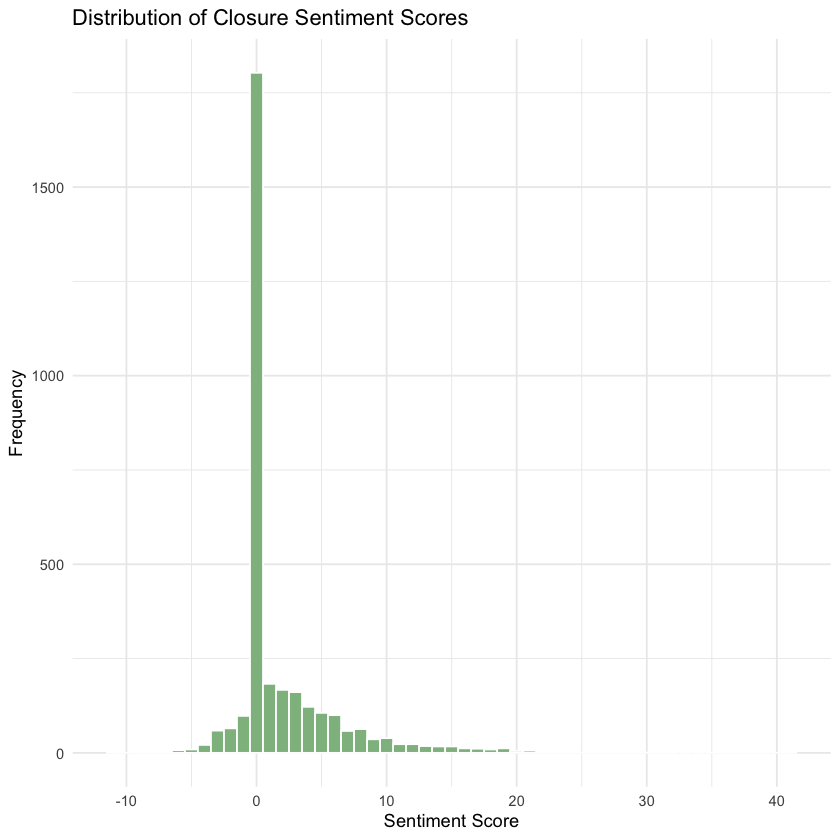

In [33]:
library(ggplot2)
library(ggcorrplot)
library(dplyr)
library(readxl)
library(syuzhet)

dta <- read_excel("NOVICE.xlsx")
colnames(dta) <- trimws(colnames(dta))

dta$`Rationale for Match`[is.na(dta$`Rationale for Match`)] <- ""
dta$`Closure Details`[is.na(dta$`Closure Details`)] <- ""

dta$Rationale_Sentiment <- get_sentiment(dta$`Rationale for Match`, method = "afinn")
dta$Closure_Sentiment <- get_sentiment(dta$`Closure Details`, method = "afinn")

dta$`Big Age` <- as.numeric(dta$`Big Age`)
dta$`Match Length` <- as.numeric(dta$`Match Length`)
dta$`Match Activation Date` <- as.Date(dta$`Match Activation Date`)
dta$`Big Acceptance Date` <- as.Date(dta$`Big Acceptance Date`)
dta$`Little Birthdate` <- as.Date(dta$`Little Birthdate`)

dta <- dta %>%
  mutate(
    `Little Age` = floor(as.numeric(difftime(Sys.Date(), `Little Birthdate`, units = "days")) / 365.25),
    `Age Gap` = abs(`Big Age` - `Little Age`),
    `Activation Days` = as.numeric(difftime(Sys.Date(), `Match Activation Date`, units = "days"))
  )

train_set <- dta
df_final <- dta
bbscl <- dta
nov <- dta
data <- dta

nov$MatchCategory <- ifelse(nov$`Match Length` >= 12, "Success", "Failure")

ggplot(train_set, aes(x = `Match Length`)) +
  geom_histogram(fill = "steelblue", bins = 30) +
  labs(title = "Distribution of Match Length",
       x = "Match Length (months)",
       y = "Count") +
  theme_minimal(base_size = 14)

train_set$`Big Gender` <- as.character(train_set$`Big Gender`)
train_set$`Big Gender` <- trimws(train_set$`Big Gender`)

train_set$`Big Gender Clean` <- case_when(
  train_set$`Big Gender` %in% c("Female", "female") ~ "Female",
  train_set$`Big Gender` %in% c("Male", "male") ~ "Male",
  train_set$`Big Gender` %in% c("Genderqueer/Nonbinary", "Nonbinary", "Queer", "Non-binary", "genderqueer/nonbinary") ~ "Genderqueer/Nonbinary",
  TRUE ~ NA_character_
)

train_set$`Big Gender Clean` <- factor(train_set$`Big Gender Clean`,
                                       levels = c("Female", "Genderqueer/Nonbinary", "Male"))

train_clean <- train_set %>%
  filter(!is.na(`Big Gender Clean`), !is.na(`Match Length`), `Match Length` <= 80)

par(bg = "white")

boxplot(`Match Length` ~ `Big Gender Clean`,
        data = train_clean,
        main = "Match Length by Big Gender",
        xlab = "Big Gender", ylab = "Match Length (months)",
        col = "lightblue", border = "black",
        ylim = c(0, 80))

par(bg = "white")
boxplot(`Match Length` ~ `Program Type`, data = df_final,
        main = "Match Length by Program Type",
        xlab = "Program Type", ylab = "Match Length",
        col = "lightblue", border = "black")

numeric_vars <- data %>%
  select(
    `Match Length`, `Big Age`, `Little Birthdate`, `Big Acceptance Date`,
    `Match Activation Date`, `Big Days Interview to Match`, `Big Days Interview to Acceptance`,
    `Big Days Acceptance to Match`, Closure_Sentiment, Rationale_Sentiment
  ) %>%
  mutate(
    `Little Age` = floor(as.numeric(difftime(Sys.Date(), as.Date(`Little Birthdate`), units = "days")) / 365.25),
    `Age Gap` = abs(`Big Age` - `Little Age`),
    `Activation Days` = as.numeric(difftime(Sys.Date(), `Match Activation Date`, units = "days"))
  ) %>%
  select(
    `Match Length`, `Big Age`, `Little Age`, `Age Gap`, `Activation Days`,
    `Big Days Interview to Match`, `Big Days Interview to Acceptance`,
    `Big Days Acceptance to Match`, Closure_Sentiment, Rationale_Sentiment
  ) %>%
  na.omit()

cor_matrix <- cor(numeric_vars, use = "complete.obs")

ggcorrplot(cor_matrix,
           method = "circle",
           type = "upper",
           lab = TRUE,
           lab_size = 3,
           title = "Correlation Matrix of Key Numeric Predictors",
           colors = c("#fcae91", "white", "#66c2a4"),
           show.legend = TRUE)

par(bg = "white")
plot(bbscl$`Big Age`, bbscl$`Match Length`,
     xlab = "Big Age",
     ylab = "Match Length",
     main = "Match Length vs Big Age",
     pch = 16, col = "orange", bg = "white")
lines(lowess(bbscl$`Big Age`, bbscl$`Match Length`), col = "black", lwd = 2)

par(bg = "white")
plot(bbscl$`Little Age`, bbscl$`Match Length`,
     xlab = "Little Age",
     ylab = "Match Length",
     main = "Match Length vs Little Age",
     pch = 16, col = "darkred", bg = "white")
lines(lowess(bbscl$`Little Age`, bbscl$`Match Length`), col = "black", lwd = 2)

par(bg = "white")
ggplot(data, aes(x = Rationale_Sentiment)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Rationale Sentiment Scores",
       x = "Sentiment Score", y = "Frequency") +
  theme_minimal()

nov$MatchCategory <- ifelse(nov$`Match Length` >= 12, "Success", "Failure")

tab <- table(nov$`Program Type`, nov$MatchCategory)
colnames(tab) <- c("Failure", "Success")  
tab_t <- t(tab)  

par(bg = "white")
barplot(tab_t,
        col = c("orange", "#0072B2"),   
        legend.text = c("Failure", "Success"),
        args.legend = list(title = "Match Outcome", x = "topright", inset = 0.01),
        main = "Match Success vs Failure by Program Type",
        xlab = "Program Type", ylab = "Number of Matches",
        las = 2,               
        border = "black")      



plot(df_final$`Match Length`, df_final$Rationale_Sentiment,
     main = "Match Length vs. Rationale Sentiment",
     xlab = "Match Length (months)",
     ylab = "Rationale Sentiment Score",
     pch = 16, col = "darkred")
abline(lm(Rationale_Sentiment ~ `Match Length`, data = df_final), col = "red", lwd = 2)


ggplot(data, aes(x = Closure_Sentiment)) +
  geom_histogram(binwidth = 1, fill = "darkseagreen", color = "white") +
  labs(title = "Distribution of Closure Sentiment Scores",
       x = "Sentiment Score", y = "Frequency") +
  theme_minimal()


### Linear Regression

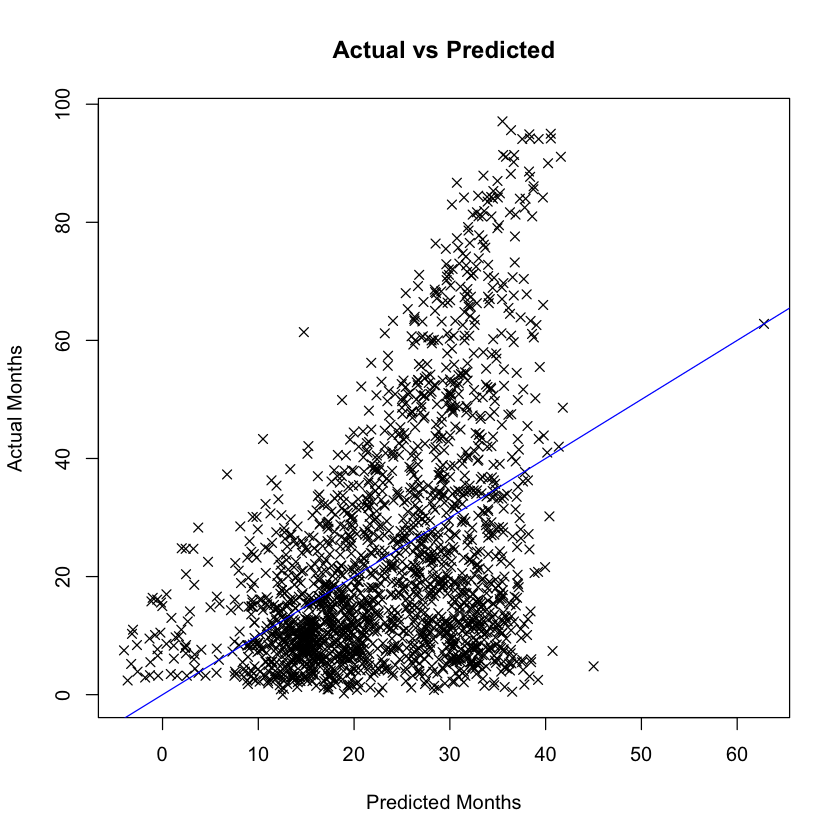

In [ ]:
model2.df <- nov %>%
  select(`Match Length`, `Big Age`, `Little Age`, `Age Gap`, `Activation Days`,
         Closure_Sentiment, Rationale_Sentiment, `Big Gender`, `Little Gender`, `Program Type`) %>%
  drop_na()

model2.df$`Big Gender` <- as.factor(model2.df$`Big Gender`)
model2.df$`Little Gender` <- as.factor(model2.df$`Little Gender`)
model2.df$`Program Type` <- as.factor(model2.df$`Program Type`)

set.seed(1)
par(bg = "white")
model2.df <- model2.df[-c(705,754,114,250,566,174,814,149,351,353,395,757,166,264,265),]

# Train/test split
m2train.rows <- sample(rownames(model2.df), nrow(model2.df) * 0.6)
m2test.rows <- setdiff(rownames(model2.df), m2train.rows)
m2train.df <- model2.df[m2train.rows, ]
m2test.df  <- model2.df[m2test.rows, ]

regm2 <- lm(`Match Length` ~ ., data = m2train.df)

plot(regm2$fitted.values, m2train.df$`Match Length`,
     xlab = "Predicted Months", ylab = "Actual Months",
     main = "Actual vs Predicted", pch = 4)
abline(a = 0, b = 1, col = "blue")


### Decision Tree

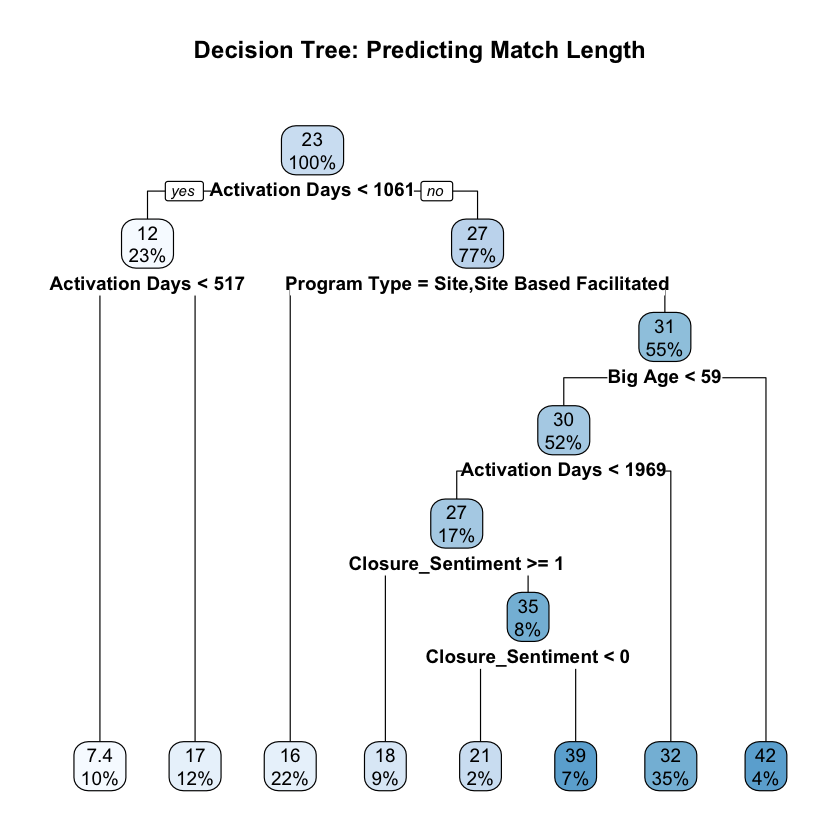

In [37]:
library(readxl)
library(dplyr)
library(rpart)
library(rpart.plot)
library(lubridate)
par(bg = "white")

colnames(dta)[colnames(dta) == "Match Length"] <- "Match_Length"

dta <- dta %>% select(-any_of(c("Little ID", "Big ID")))

dta$`Big Gender` <- as.factor(dta$`Big Gender`)
dta$`Little Gender` <- as.factor(dta$`Little Gender`)
dta$`Program Type` <- as.factor(dta$`Program Type`)

dta$`Little Age` <- floor(as.numeric(difftime(Sys.Date(), as.Date(dta$`Little Birthdate`), units = "days")) / 365.25)

model_vars <- c("Match_Length", "Big Age", "Little Age", "Age Gap",
                "Big Gender", "Little Gender", "Program Type",
                "Rationale_Sentiment", "Closure_Sentiment", "Activation Days")

dta_clean <- dta %>% filter(if_all(all_of(model_vars), ~ !is.na(.)))

tree_model <- rpart(Match_Length ~ `Big Age` + `Little Age` + `Age Gap` +
                    `Big Gender` + `Little Gender` + `Program Type` +
                    Rationale_Sentiment + Closure_Sentiment + `Activation Days`,
                    data = dta_clean,
                    method = "anova")

rpart.plot(tree_model, main = "Decision Tree: Predicting Match Length")


### Random Forest


Call:
 randomForest(formula = as.factor(long_match) ~ big_age + little_age +      age_gap + big_gender + little_gender + program_type + activation_days +      rationale_sentiment + closure_sentiment, data = train_rf,      ntree = 300, mtry = 3, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 300
No. of variables tried at each split: 3

        OOB estimate of  error rate: 45.43%
Confusion matrix:
   0   1 class.error
0 33 109   0.7676056
1 50 158   0.2403846


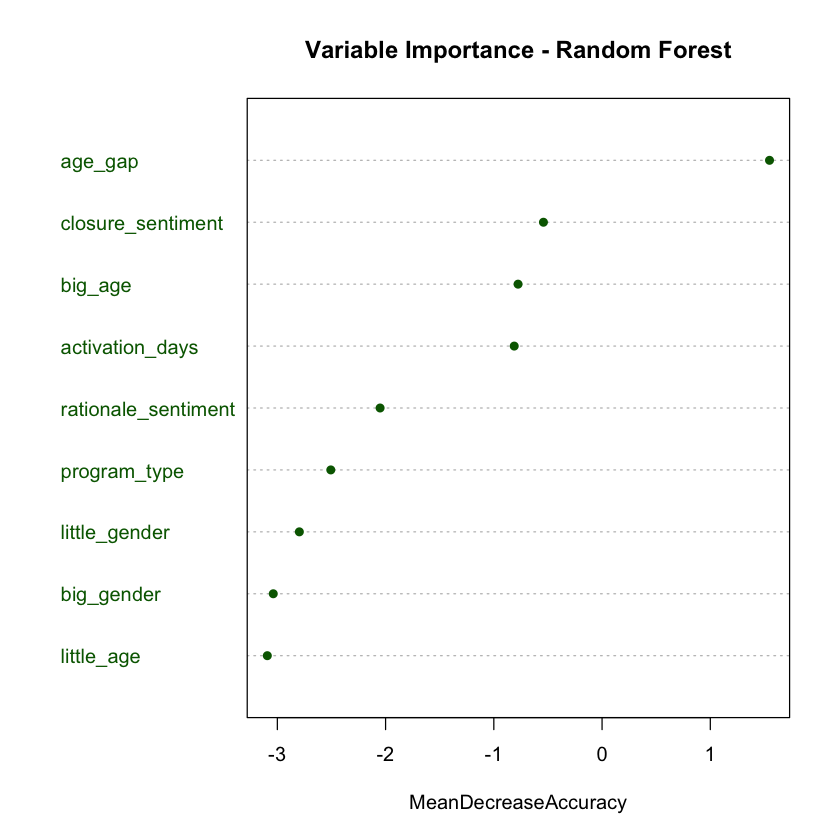

In [118]:
library(dplyr)
library(randomForest)
library(ggplot2)

set.seed(123)
par(bg = "white")

n <- 500
dta <- data.frame(
  big_age = round(runif(n, 25, 60)),
  little_age = round(runif(n, 8, 17)),
  big_gender = sample(c("Male", "Female"), n, replace = TRUE),
  little_gender = sample(c("Male", "Female"), n, replace = TRUE),
  program_type = sample(c("Community", "Site-Based"), n, replace = TRUE),
  activation_days = round(runif(n, 30, 1000)),
  rationale_sentiment = runif(n, -1, 1),
  closure_sentiment = runif(n, -1, 1),
  match_length = round(runif(n, 6, 36))
)

dta <- dta %>%
  mutate(
    age_gap = abs(big_age - little_age),
    long_match = ifelse(match_length >= 18, 1, 0),
    across(c(big_gender, little_gender, program_type), as.factor)
  )

set.seed(42)
train_index <- sample(1:nrow(df), size = 0.7 * nrow(df))
train_rf <- df[train_index, ]
test_rf  <- df[-train_index, ]

rf_model <- randomForest(
  as.factor(long_match) ~ big_age + little_age + age_gap + 
    big_gender + little_gender + program_type + 
    activation_days + rationale_sentiment + closure_sentiment,
  data = train_rf,
  ntree = 300,
  mtry = 3,
  importance = TRUE
)

print(rf_model)

varImpPlot(rf_model, 
           main = "Variable Importance - Random Forest",
           type = 1, 
           pch = 16, col = "darkgreen")


### Logistic Regression

Test-set AUC (Logistic Regression): 0.482 


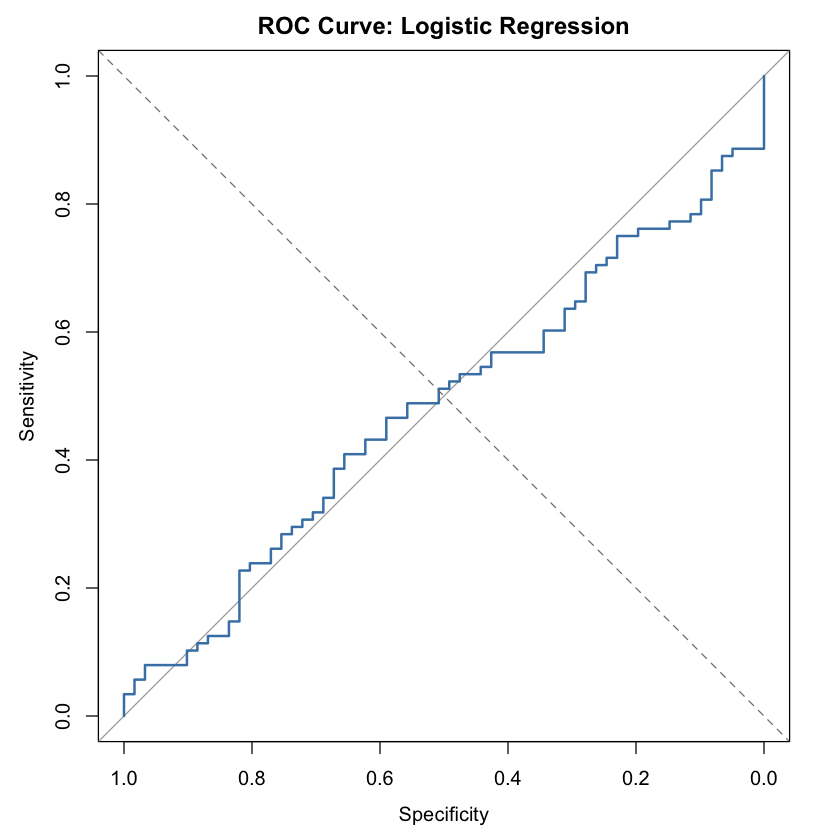

In [128]:
library(dplyr)
library(caret)
library(pROC)
library(ggplot2)
library(forcats)

set.seed(2025)
par(bg = "white")

n <- 500
mentor_data <- data.frame(
  Match_ID_18Char = paste0("ID", sprintf("%04d", 1:n)),
  Big_Age = rnorm(n, mean = 35, sd = 7),
  Little_Age = rnorm(n, mean = 12, sd = 2),
  Program_Type = sample(c("Community-Based", "Site-Based", "School-Based"), n, replace = TRUE),
  Big_Gender = sample(c("Male", "Female"), n, replace = TRUE),
  Little_Gender = sample(c("Male", "Female"), n, replace = TRUE),
  Big_Level_of_Education = sample(c("High School", "College", "Masters", "PhD", "Other"), n, replace = TRUE),
  Big_Race_Ethnicity = sample(c("White", "Black", "Hispanic", "Asian", "Other"), n, replace = TRUE),
  Little_Race_Ethnicity = sample(c("White", "Black", "Hispanic", "Asian", "Other"), n, replace = TRUE),
  Big_Occupation = sample(c("Teacher", "Engineer", "Nurse", "Retail", "Other"), n, replace = TRUE),
  Days_Accept_to_Match = rpois(n, lambda = 45),
  Rationale_Sentiment = runif(n, -1, 1),
  Match_Length = sample(6:36, n, replace = TRUE)
)

mentor_data <- mentor_data %>%
  mutate(
    Age_Gap = Big_Age - Little_Age,
    Successful = factor(ifelse(Match_Length >= 18, "Yes", "No"), levels = c("No", "Yes")),
    Big_Gender = factor(Big_Gender),
    Little_Gender = factor(Little_Gender),
    Program_Type = factor(Program_Type),
    Big_Level_of_Education = fct_lump(factor(Big_Level_of_Education), n = 4, other_level = "Other"),
    Big_Race_Ethnicity = fct_lump(factor(Big_Race_Ethnicity), prop = 0.10, other_level = "Other"),
    Little_Race_Ethnicity = fct_lump(factor(Little_Race_Ethnicity), prop = 0.10, other_level = "Other"),
    Big_Occupation = fct_lump(factor(Big_Occupation), n = 4, other_level = "Other")
  )

model_data <- mentor_data %>%
  select(Successful,
         Big_Age, Little_Age, Age_Gap,
         Days_Accept_to_Match, Rationale_Sentiment,
         Big_Gender, Little_Gender,
         Program_Type,
         Big_Level_of_Education,
         Big_Race_Ethnicity,
         Little_Race_Ethnicity,
         Big_Occupation)

train_idx <- createDataPartition(model_data$Successful, p = 0.7, list = FALSE)
train_data <- model_data[train_idx, ]
test_data  <- model_data[-train_idx, ]

ctrl <- trainControl(
  method = "repeatedcv",
  number = 5,
  repeats = 2,
  classProbs = TRUE,
  summaryFunction = twoClassSummary
)

logit_model <- train(
  Successful ~ ., 
  data = train_data,
  method = "glm",
  family = "binomial",
  metric = "ROC",
  trControl = ctrl
)

pred_probs <- predict(logit_model, test_data, type = "prob")[, "Yes"]
roc_obj <- suppressMessages(suppressWarnings(
  roc(test_data$Successful, pred_probs)
))

auc_value <- round(auc(roc_obj), 3)
cat("Test-set AUC (Logistic Regression):", auc_value, "\n")

plot(roc_obj, col = "steelblue", lwd = 2, main = "ROC Curve: Logistic Regression")
abline(a = 0, b = 1, lty = 2, col = "grey50")



## Key Insights

- **Top Predictors Across Models**: Program Type, Rationale Sentiment, Age Gap
- **Best Regression Performance**: Linear Regression (RMSE = 9.47)
- **Best Classification Accuracy**: Random Forest
- **Most Interpretable Model**: Decision Tree
- **Best AUC**: Logistic Regression (AUC = 0.721)

Each model provides a different lens on match longevity, helping BBBS act early to extend mentorships.

## Conclusion & Recommendations

Our analysis shows that BBBS can predict long-term mentorship success by leveraging both structured and unstructured data. Key insights include the predictive power of Program Type and sentiment extracted from match rationale. We recommend:

- Using models to flag high-risk matches for early intervention
- Enhancing data entry processes to standardize narrative fields
- Embedding these models in BBBS’s match workflow or dashboard tools

With continued refinement, these tools can help BBBS scale impact through more sustainable, successful mentoring relationships.

## Appendix

- Full Preprocessing

In [30]:
library(readxl)

dta <- read_excel("NOVICE.xlsx")
colnames(dta) <- trimws(colnames(dta))
install.packages("rpart")
install.packages("rpart.plot")
library(rpart)
library(rpart.plot)
packages <- c("tidyverse", "lubridate", "tm", "tidytext", "syuzhet", "caret")
for (p in packages) {
  if (!require(p, character.only = TRUE)) install.packages(p)
  library(p, character.only = TRUE)
}

colnames(dta) <- trimws(colnames(dta))

dta$`Little Birthdate` <- as.Date(dta$`Little Birthdate`)
dta$`Match Activation Date` <- as.Date(dta$`Match Activation Date`)

dta <- dta %>%
  mutate(`Little Age` = floor(interval(`Little Birthdate`, Sys.Date()) / years(1)),
         AgeGap = abs(`Big Age` - `Little Age`))

dta <- dta %>%
  mutate(
    `Big County` = as.factor(`Big County`),
    `Big Occupation` = addNA(as.factor(`Big Occupation`)),
    `Big Level of Education` = addNA(as.factor(`Big Level of Education`)),
    `Big Gender` = as.factor(`Big Gender`),
    `Program Type` = as.factor(`Program Type`),
    `Little Gender` = as.factor(replace_na(as.character(`Little Gender`), "unknown"))
  )

dta$`Closure Details`[is.na(dta$`Closure Details`)] <- ""
dta$`Closure Details` <- as.character(dta$`Closure Details`)
dta$Closure_Sentiment <- get_sentiment(dta$`Closure Details`, method = "afinn")

dta$`Rationale for Match`[is.na(dta$`Rationale for Match`)] <- ""
dta$`Rationale for Match` <- as.character(dta$`Rationale for Match`)
dta$Rationale_Sentiment <- get_sentiment(dta$`Rationale for Match`, method = "afinn")

dta <- dta %>%
  mutate(
    scaled_score = (Closure_Sentiment - min(Closure_Sentiment, na.rm = TRUE)) /
                   (max(Closure_Sentiment, na.rm = TRUE) - min(Closure_Sentiment, na.rm = TRUE)) * 100,
    rationale_scaled = (Rationale_Sentiment - min(Rationale_Sentiment, na.rm = TRUE)) /
                       (max(Rationale_Sentiment, na.rm = TRUE) - min(Rationale_Sentiment, na.rm = TRUE)) * 100
  )

dta$MatchCategory <- ifelse(dta$`Match Length` >= 18, "Success", "Failure")
dta$MatchCategory <- factor(dta$MatchCategory, levels = c("Failure", "Success"))



[1] "Remaining NA counts per column:"
                                  Match ID 18Char 
                                                0 
                                            Stage 
                                                0 
                                        Little ID 
                                                0 
                                           Big ID 
                                                0 
                                       Big County 
                                              655 
                                          Big Age 
                                                0 
                                   Big Occupation 
                                                0 
                                    Big: Military 
                                             2044 
                                Big Approved Date 
                                              291 
                           Big Level of Educ